In [7]:
import numpy as np
import matplotlib.pyplot as plt

### 1. HELPER FUNCTIONS

In [8]:
def adjacent(cluster, x, y):
    ny, nx = cluster.shape

    # necessary if the cluster reaches the top (and a walker is released on it)
    if cluster[y, x] == 1:
        return False

    if x == 0:
        if cluster[y, nx - 1] == 1:
            return True
    else:
        if cluster[y, x - 1] == 1:
            return True

    if x == nx - 1:
        if cluster[y, 0] == 1:
            return True
    else:
        if cluster[y, x + 1] == 1:
            return True

    y_up = y - 1
    y_down = y + 1

    if y_up >= 0:
        if cluster[y_up, x] == 1:
            return True

    if y_down < ny:
        if cluster[y_down, x] == 1:
            return True

    return False


def random_step(x, y):
    direction = np.random.randint(0, 4)

    if direction == 0:
        x = x + 1
    elif direction == 1:
        x = x - 1
    elif direction == 2:
        y = y + 1
    else:
        y = y - 1

    return x, y



### 2. WALKER

In [9]:
def run_single_walker(cluster, p_s, max_steps):
    ny, nx = cluster.shape

    x = np.random.randint(0, nx)
    y = 0

    steps = 0

    while steps < max_steps:
        steps = steps + 1

        if adjacent(cluster, x, y) is True:
            r = np.random.rand()

            if r < p_s:
                cluster[y, x] = 1
                return True, steps

        new_x, new_y = random_step(x, y)

        # BC in horizontal direction
        if new_x < 0:
            new_x = nx - 1
        elif new_x >= nx:
            new_x = 0

        # BC in vertical direction
        if new_y < 0 or new_y >= ny:
            return False, steps

        # Impede the walker to move into the cluster
        if cluster[new_y, new_x] == 1:
            continue

        x = new_x
        y = new_y

    return False, steps



### 3. DLA SIMULATION

In [10]:
def simulate_dla(nx, ny, n_particles, p_s, max_steps_walker):

    cluster = np.zeros((ny, nx), int)
    seed_x = nx // 2
    seed_y = ny - 1
    cluster[seed_y, seed_x] = 1

    particles_added = 0
    walkers_released = 0
    total_steps = 0

    while particles_added < n_particles:
        walkers_released = walkers_released + 1

        stuck, steps = run_single_walker(cluster, p_s, max_steps_walker)

        total_steps = total_steps + steps

        if stuck:
            particles_added = particles_added + 1

    return cluster, walkers_released, total_steps


### 4. PART C

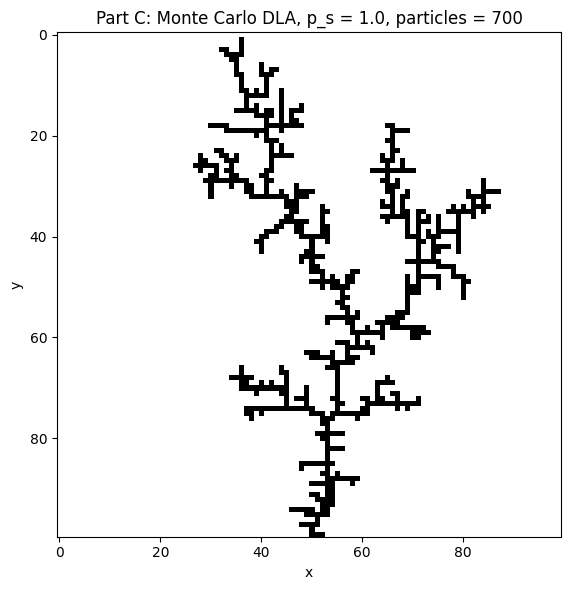

PART C
Successful added particles = 700
Total walkers released     = 63973
Total random-walk steps    = 10156880


In [11]:
nx = 100
ny = 100
n_particles = 700
max_steps_walker = 100000

cluster_c, walkers_c, steps_c = simulate_dla(nx, ny, n_particles, 1, max_steps_walker)

plt.figure(figsize=(6, 6))
plt.imshow(cluster_c, cmap="binary", origin="upper")
plt.title(f"Part C: Monte Carlo DLA, p_s = 1.0, particles = {n_particles}")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

print("PART C")
print("Successful added particles =", n_particles)
print("Total walkers released     =", walkers_c)
print("Total random-walk steps    =", steps_c)


### 5. PART D

PART D
p_s                          = 1.0
Successful added particles   = 700
Total walkers released       = 85717
Total random-walk steps      = 14105049


PART D
p_s                          = 0.5
Successful added particles   = 700
Total walkers released       = 83732
Total random-walk steps      = 13615077


PART D
p_s                          = 0.2
Successful added particles   = 700
Total walkers released       = 87115
Total random-walk steps      = 14773805


PART D
p_s                          = 0.05
Successful added particles   = 700
Total walkers released       = 146525
Total random-walk steps      = 27425988




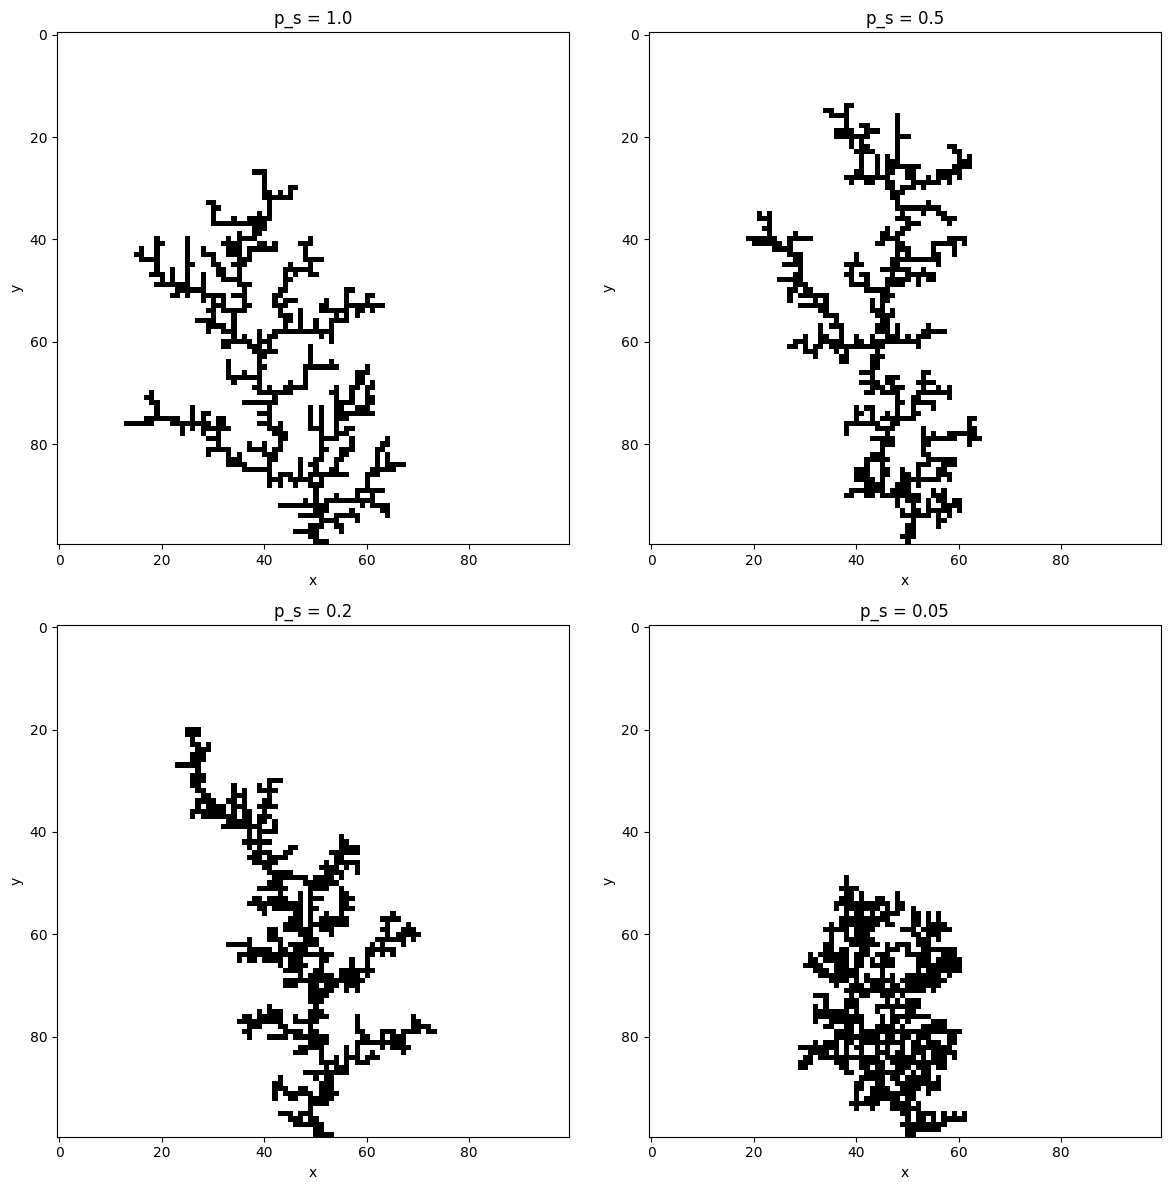

In [12]:
ps_values = [1.0, 0.5, 0.2, 0.05]

clusters_d = []
titles_d = []

for ps in ps_values:
    cluster_d, walkers_d, steps_d = simulate_dla(nx, ny, n_particles, ps, max_steps_walker)

    clusters_d.append(cluster_d)
    titles_d.append(f"p_s = {ps}")

    print("PART D")
    print("p_s                          =", ps)
    print("Successful added particles   =", n_particles)
    print("Total walkers released       =", walkers_d)
    print("Total random-walk steps      =", steps_d)
    print("\n")


plt.figure(figsize=(6 * 2, 6 * 2))

for k in range(4):
    plt.subplot(2, 2, k + 1)
    plt.imshow(clusters_d[k], cmap="binary", origin="upper")
    plt.title(titles_d[k])
    plt.xlabel("x")
    plt.ylabel("y")

plt.tight_layout()
plt.show()
